# Sistema dinamico de recomendacion basado en likes simulados

Este notebook estudia la capa dinamica de un recomendador basado en embeddings semanticos. El objetivo no es reentrenar modelos ni cambiar la arquitectura base, sino analizar por que una recomendacion por similitud coseno puede volverse demasiado concentrada y evaluar una mejora sencilla basada en diversidad.

La logica del notebook es:

1. Analizar la geometria del dataset y de sus embeddings.
2. Diagnosticar las causas de la concentracion del ranking.
3. Definir una linea base por maxima similitud coseno.
4. Compararla con una version que penaliza repeticiones de categoria.
5. Evaluar varios usuarios simulados y un caso simple con feedback negativo.


## 1. Carga de artefactos y configuracion

Se reutilizan los embeddings generados en el notebook 02. El flujo esperado es cargar `artifacts/embeddings_posts.joblib`, que contiene tanto la matriz de embeddings como el dataframe preparado. Si ese artefacto no existe o no es compatible con la version local de las librerias, se usan los metadatos de `models/clasificador_embeddings.joblib` y el modelo local `models/modelo_embeddings` para reconstruirlo.


In [ ]:
import re
from itertools import combinations
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics.pairwise import cosine_similarity

ARTIFACTS_PATH = Path("artifacts/embeddings_posts.joblib")
EMBEDDING_METADATA_PATH = Path("models/clasificador_embeddings.joblib")
EMBEDDING_MODEL_DIR = Path("models/modelo_embeddings")
DATA_PATH = Path("data/posts.csv")

TOP_K = 10
LAMBDA_DIVERSIDAD_DEFECTO = 0.03
LAMBDAS_A_PROBAR = [0.00, 0.03, 0.05, 0.08, 0.10]
RANDOM_STATE = 42

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 30)


In [ ]:
required_columns = {"texto_limpio", "categoria"}

try:
    artefacto = joblib.load(ARTIFACTS_PATH)
    required_keys = {"embeddings", "posts"}
    if not required_keys.issubset(artefacto):
        raise ValueError(
            f"El artefacto debe contener las claves {required_keys}. Claves disponibles: {sorted(artefacto.keys())}"
        )

    embeddings_posts = np.asarray(artefacto["embeddings"], dtype=np.float32)
    df_modelo = artefacto["posts"].copy().reset_index(drop=True)
    embedding_model_name = artefacto.get("embedding_model_name", "desconocido")
    embedding_model_dir = Path(artefacto.get("embedding_model_dir", EMBEDDING_MODEL_DIR))
    origen_carga = f"artefacto persistido en {ARTIFACTS_PATH}"
except Exception as exc:
    if not EMBEDDING_METADATA_PATH.exists():
        raise FileNotFoundError(
            "No se encontro el artefacto de embeddings ni los metadatos del modelo. "
            "Ejecuta antes el notebook 02 para generar "
            f"{ARTIFACTS_PATH} y {EMBEDDING_METADATA_PATH}."
        ) from exc

    metadata_embeddings = joblib.load(EMBEDDING_METADATA_PATH)
    embedding_model_name = metadata_embeddings.get(
        "embedding_model_name",
        "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    )
    embedding_model_dir = Path(metadata_embeddings.get("embedding_model_dir", EMBEDDING_MODEL_DIR))

    df = pd.read_csv(DATA_PATH, encoding="utf-8")
    df = df[["id", "descripcion", "hashtags", "categoria"]].copy()
    df["texto_original"] = (
        df["descripcion"].fillna("").astype(str).str.strip()
        + " "
        + df["hashtags"].fillna("").astype(str).str.strip()
    ).str.replace(r"\s+", " ", regex=True).str.strip()

    def preprocesar_texto(texto):
        texto = str(texto).lower().replace("#", " ")
        texto = re.sub(r"[^a-zA-Z0-9??????????????\s]", " ", texto)
        texto = re.sub(r"\s+", " ", texto).strip()
        return texto

    df["texto_limpio"] = df["texto_original"].apply(preprocesar_texto)
    df_modelo = df[df["texto_limpio"].str.len() > 0].copy().reset_index(drop=True)

    try:
        from sentence_transformers import SentenceTransformer
    except ImportError as import_exc:
        raise ImportError(
            "No se pudo leer el artefacto serializado y tampoco esta disponible sentence-transformers para regenerar embeddings."
        ) from import_exc

    if embedding_model_dir.exists():
        modelo_embeddings = SentenceTransformer(str(embedding_model_dir), local_files_only=True)
        origen_modelo_embeddings = f"modelo local persistido en {embedding_model_dir}"
    else:
        modelo_embeddings = SentenceTransformer(embedding_model_name)
        origen_modelo_embeddings = f"modelo importado desde {embedding_model_name}"

    embeddings_posts = modelo_embeddings.encode(
        df_modelo["texto_limpio"].tolist(),
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    embeddings_posts = embeddings_posts.astype(np.float32)

    ARTIFACTS_PATH.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(
        {
            "embeddings": embeddings_posts,
            "posts": df_modelo[["id", "descripcion", "hashtags", "categoria", "texto_original", "texto_limpio"]].copy(),
            "embedding_model_name": embedding_model_name,
            "embedding_model_dir": str(embedding_model_dir),
            "text_column": "texto_limpio",
            "data_path": str(DATA_PATH),
        },
        ARTIFACTS_PATH,
    )
    origen_carga = (
        f"fallback activado por {exc.__class__.__name__}; "
        f"embeddings regenerados con {origen_modelo_embeddings} y guardados en {ARTIFACTS_PATH}"
    )

if not required_columns.issubset(df_modelo.columns):
    raise ValueError(
        f"df_modelo debe incluir las columnas {required_columns}. Columnas disponibles: {df_modelo.columns.tolist()}"
    )

if len(df_modelo) != len(embeddings_posts):
    raise ValueError(
        "El numero de filas de df_modelo no coincide con el numero de embeddings. "
        f"Filas: {len(df_modelo)} | Embeddings: {len(embeddings_posts)}"
    )

embeddings_posts = np.asarray(embeddings_posts, dtype=np.float32)
embeddings_norm = embeddings_posts / np.clip(np.linalg.norm(embeddings_posts, axis=1, keepdims=True), 1e-12, None)
df_modelo = df_modelo.reset_index(drop=True)
df_modelo["longitud_texto"] = df_modelo["texto_limpio"].str.split().str.len()

print(f"Origen de carga: {origen_carga}")
print(f"Modelo de embeddings: {embedding_model_name}")
print(f"Directorio local del modelo: {embedding_model_dir}")
print(f"Matriz de embeddings: {embeddings_norm.shape[0]} posts x {embeddings_norm.shape[1]} dimensiones")
display(df_modelo[["categoria", "texto_limpio"]].head())


## 2. Analisis previo del dataset

Antes de evaluar recomendaciones conviene mirar si el propio dataset favorece rankings homogeneos. Si una categoria tiene muchos ejemplos, textos muy parecidos entre si y una separacion alta respecto al resto, un ranking por similitud tendera a explotar esa zona del espacio vectorial.


Numero de categorias: 8
Ratio de desbalance max/min: 1.10
Distribucion de posts por categoria:


,categoria,n_posts,porcentaje
0,playa,644,13.06
1,cocina,641,13.00
2,viajes,626,12.70
3,coches,622,12.61
4,musica,614,12.45
5,videojuegos,612,12.41
6,deporte,587,11.90
7,animales,585,11.86


Longitud media de texto por categoria:


,categoria,n_posts,longitud_media,longitud_mediana,longitud_std
5,playa,644,33.80,14.0,194.17
2,cocina,641,27.73,13.0,146.10
6,viajes,626,29.34,12.0,179.39
1,coches,622,25.45,12.0,160.28
4,musica,614,25.91,13.0,145.51
7,videojuegos,612,24.49,13.0,124.87
3,deporte,587,34.81,13.0,202.16
0,animales,585,21.62,16.0,116.21


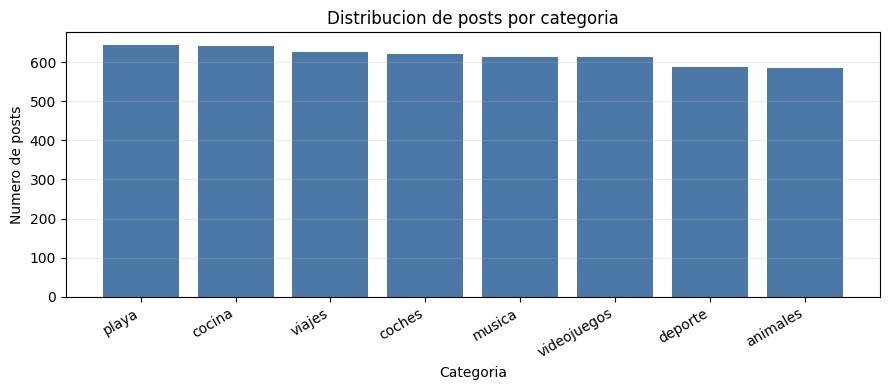

In [ ]:
conteo_categorias = df_modelo["categoria"].value_counts().rename_axis("categoria").reset_index(name="n_posts")
conteo_categorias["porcentaje"] = (100 * conteo_categorias["n_posts"] / len(df_modelo)).round(2)

longitud_por_categoria = (
    df_modelo.groupby("categoria")["longitud_texto"]
    .agg(n_posts="size", longitud_media="mean", longitud_mediana="median", longitud_std="std")
    .round(2)
    .reset_index()
    .sort_values("n_posts", ascending=False)
)

n_categorias = df_modelo["categoria"].nunique()
ratio_desbalance = conteo_categorias["n_posts"].max() / conteo_categorias["n_posts"].min()

print(f"Numero de categorias: {n_categorias}")
print(f"Ratio de desbalance max/min: {ratio_desbalance:.2f}")
print("Distribucion de posts por categoria:")
display(conteo_categorias)

print("Longitud media de texto por categoria:")
display(longitud_por_categoria)

plt.figure(figsize=(9, 4))
plt.bar(conteo_categorias["categoria"], conteo_categorias["n_posts"], color="#4C78A8")
plt.title("Distribucion de posts por categoria")
plt.xlabel("Categoria")
plt.ylabel("Numero de posts")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


In [ ]:
print("Muestras de textos por categoria:")
for categoria in sorted(df_modelo["categoria"].unique()):
    muestras = (
        df_modelo[df_modelo["categoria"].eq(categoria)][["texto_limpio"]]
        .sample(min(3, df_modelo["categoria"].eq(categoria).sum()), random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )
    print(f"\nCategoria: {categoria}")
    display(muestras)


Muestras de textos por categoria:

Categoria: animales


,texto_limpio
0,de paseo por vizcaya el veterinario dice que está perfectamente sano qué bonitos son doglife animales adopta mascota...
1,el veterinario dice que está perfectamente sano necesito 20 más perros
2,literalmente el mejor momento del día mi perro corriendo como un loco por el parque perros catlife michis



Categoria: coches


,texto_limpio
0,increíble el motor v8 rugiendo como una bestia me encanta drifting velocidad
1,hoy toca ruta por girona derrape guapo en la última rotonda puro vicio cochesclasicos tuning llantas
2,enamorado de este bicho el motor v8 rugiendo como una bestia gas v8 llantas jdm



Categoria: cocina


...

,texto_limpio
0,adivinad quien esta en las palmas modo cangrejo activado me he quemado entero que paz bronceado chiringuito postu
1,tarde perfecta en el chiringuito con un mojito 10 10 calor olas vistas playa desconexion
2,madre mía tarde perfecta en el chiringuito con un mojito 10 10



Categoria: viajes


,texto_limpio
0,escapada express perdido en el metro de sudan ayuda
1,escapada express probando street food de dudosa procedencia wanderlust total explorando ruta sinfiltros
2,escapada express haciendo el check in con tomasa xd



Categoria: videojuegos


,texto_limpio
0,increíble farmeando xp como un tryhard para hacer level up f en el chat xd indiegames levelup tryhard setup
1,abriendo loot boxes y solo sale humo f en el chat indiegames discord pcgaming esports tryhard
2,increible ese boss tiene una hitbox rotisima xd gamer


### Similitud intra-categoria e inter-categoria

La similitud media intra-categoria mide cuanto se parecen entre si los posts de una misma categoria. La similitud media inter-categoria mide cuanto se parecen posts de categorias distintas.

Para el promedio exacto se usan embeddings normalizados. En ese caso, la media de similitudes entre grupos puede calcularse a partir de sumas vectoriales sin construir matrices enormes de pares. Para visualizar distribuciones se toma una muestra reproducible de pares.


In [ ]:
def similitud_intra_media_exacta(indices):
    vectores = embeddings_norm[indices]
    n = len(vectores)
    if n < 2:
        return np.nan
    suma = vectores.sum(axis=0)
    suma_pares = float(np.dot(suma, suma) - n)
    return suma_pares / (n * (n - 1))


def similitud_inter_media_exacta(indices_a, indices_b):
    vectores_a = embeddings_norm[indices_a]
    vectores_b = embeddings_norm[indices_b]
    return float(np.dot(vectores_a.mean(axis=0), vectores_b.mean(axis=0)))


indices_por_categoria = {
    categoria: df_modelo.index[df_modelo["categoria"].eq(categoria)].to_numpy()
    for categoria in sorted(df_modelo["categoria"].unique())
}

filas_intra = []
for categoria, indices in indices_por_categoria.items():
    filas_intra.append(
        {
            "categoria": categoria,
            "n_posts": len(indices),
            "similitud_media_intra": similitud_intra_media_exacta(indices),
        }
    )

df_similitud_intra = pd.DataFrame(filas_intra).sort_values("similitud_media_intra", ascending=False)
df_similitud_intra["similitud_media_intra"] = df_similitud_intra["similitud_media_intra"].round(4)

filas_inter = []
for categoria_a, categoria_b in combinations(indices_por_categoria.keys(), 2):
    filas_inter.append(
        {
            "categoria_a": categoria_a,
            "categoria_b": categoria_b,
            "similitud_media_inter": similitud_inter_media_exacta(
                indices_por_categoria[categoria_a],
                indices_por_categoria[categoria_b],
            ),
        }
    )

df_similitud_inter = pd.DataFrame(filas_inter).sort_values("similitud_media_inter", ascending=False)
df_similitud_inter["similitud_media_inter"] = df_similitud_inter["similitud_media_inter"].round(4)

similitud_intra_global = float(
    np.average(df_similitud_intra["similitud_media_intra"], weights=df_similitud_intra["n_posts"])
)
similitud_inter_global = float(df_similitud_inter["similitud_media_inter"].mean())
separacion_intra_inter = similitud_intra_global - similitud_inter_global

print("Similitud media intra-categoria:")
display(df_similitud_intra)

print("Pares de categorias semanticamente mas parecidos:")
display(df_similitud_inter.head(12))

print(f"Similitud intra global ponderada: {similitud_intra_global:.4f}")
print(f"Similitud inter global media: {similitud_inter_global:.4f}")
print(f"Separacion intra - inter: {separacion_intra_inter:.4f}")


Similitud media intra-categoria:


,categoria,n_posts,similitud_media_intra
0,animales,585,0.5212
4,musica,614,0.5192
2,cocina,641,0.5062
1,coches,622,0.4585
6,viajes,626,0.4582
3,deporte,587,0.4131
5,playa,644,0.4052
7,videojuegos,612,0.3836


Pares de categorias semanticamente mas parecidos:


,categoria_a,categoria_b,similitud_media_inter
15,cocina,playa,0.2755
24,musica,videojuegos,0.2470
13,cocina,deporte,0.2401
25,playa,viajes,0.2385
19,deporte,playa,0.2374
9,coches,musica,0.2355
21,deporte,videojuegos,0.2346
12,coches,videojuegos,0.2330
7,coches,cocina,0.2321
22,musica,playa,0.2306


Similitud intra global ponderada: 0.4580
Similitud inter global media: 0.1995
Separacion intra - inter: 0.2585


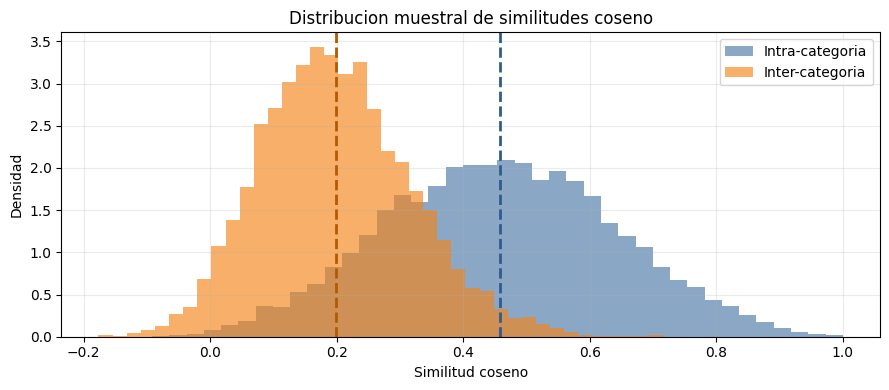

In [ ]:
rng = np.random.default_rng(RANDOM_STATE)
pares_intra = []
pares_inter = []

for categoria, indices in indices_por_categoria.items():
    n_muestras = min(1200, len(indices) * 2)
    a = rng.choice(indices, size=n_muestras, replace=True)
    b = rng.choice(indices, size=n_muestras, replace=True)
    mascara = a != b
    similitudes = np.sum(embeddings_norm[a[mascara]] * embeddings_norm[b[mascara]], axis=1)
    pares_intra.extend(similitudes.tolist())

categorias = np.array(list(indices_por_categoria.keys()))
for _ in range(9000):
    categoria_a, categoria_b = rng.choice(categorias, size=2, replace=False)
    indice_a = rng.choice(indices_por_categoria[categoria_a])
    indice_b = rng.choice(indices_por_categoria[categoria_b])
    pares_inter.append(float(np.dot(embeddings_norm[indice_a], embeddings_norm[indice_b])))

plt.figure(figsize=(9, 4))
plt.hist(pares_intra, bins=40, alpha=0.65, label="Intra-categoria", color="#4C78A8", density=True)
plt.hist(pares_inter, bins=40, alpha=0.65, label="Inter-categoria", color="#F58518", density=True)
plt.axvline(np.mean(pares_intra), color="#2F5C8A", linestyle="--", linewidth=2)
plt.axvline(np.mean(pares_inter), color="#B35A00", linestyle="--", linewidth=2)
plt.title("Distribucion muestral de similitudes coseno")
plt.xlabel("Similitud coseno")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 3. Diagnostico del problema actual

El comportamiento plano del recomendador se explica por la interaccion entre el dataset y la regla de ranking:

- Si la similitud intra-categoria queda claramente por encima de la similitud inter-categoria, las categorias forman regiones relativamente compactas. En ese escenario, un perfil construido con likes de una categoria cae cerca de esa region y el top-k tiende a llenarse con la misma etiqueta.
- Si algunos pares de categorias tienen similitud inter-categoria alta, el sistema puede mezclar resultados, pero esa mezcla no siempre implica diversidad util: puede reflejar ambiguedad semantica entre categorias cercanas.
- La media simple de embeddings resume todos los likes en una sola direccion. Cuando una categoria domina el historial, esa direccion se desplaza hacia su centroide y reduce la exposicion a intereses secundarios.
- La recomendacion por maxima similitud coseno optimiza explotacion local: devuelve los items mas cercanos al perfil, aunque todos pertenezcan a la misma categoria.
- Una `Precision@K` basada solo en coincidencia de categoria puede ser poco informativa. Un ranking con diez posts de la categoria dominante puede parecer perfecto aunque sea redundante y tenga baja diversidad.

Por tanto, el problema no esta necesariamente en los embeddings, sino en usar un unico objetivo de ranking: maxima similitud individual sin ningun termino de exploracion, cobertura o diversidad.


In [ ]:
if separacion_intra_inter > 0.08:
    lectura_separacion = "alta"
elif separacion_intra_inter > 0.03:
    lectura_separacion = "moderada"
else:
    lectura_separacion = "baja"

categoria_mas_compacta = df_similitud_intra.iloc[0]
par_mas_cercano = df_similitud_inter.iloc[0]

texto_diagnostico = f'''
**Lectura especifica del dataset cargado**

- La similitud intra-categoria global es `{similitud_intra_global:.4f}` y la similitud inter-categoria media es `{similitud_inter_global:.4f}`. La separacion observada es `{separacion_intra_inter:.4f}`, por lo que la separabilidad semantica es **{lectura_separacion}**.
- La categoria con mayor cohesion interna es `{categoria_mas_compacta['categoria']}` con una similitud intra media de `{categoria_mas_compacta['similitud_media_intra']:.4f}`. Si un usuario acumula likes en esa zona, es esperable que el top-k se concentre ahi.
- El par de categorias mas cercano semanticamente es `{par_mas_cercano['categoria_a']}` - `{par_mas_cercano['categoria_b']}` con similitud inter media `{par_mas_cercano['similitud_media_inter']:.4f}`. Estas categorias son candidatas naturales a aparecer juntas cuando el perfil sea mixto.
- El ratio de desbalance max/min es `{ratio_desbalance:.2f}`. Si este valor es bajo, la concentracion del ranking se explica mas por la geometria semantica que por una falta extrema de ejemplos en categorias minoritarias.
'''

display(Markdown(texto_diagnostico))



**Lectura especifica del dataset cargado**

- La similitud intra-categoria global es `0.4580` y la similitud inter-categoria media es `0.1995`. La separacion observada es `0.2585`, por lo que la separabilidad semantica es **alta**.
- La categoria con mayor cohesion interna es `animales` con una similitud intra media de `0.5212`. Si un usuario acumula likes en esa zona, es esperable que el top-k se concentre ahi.
- El par de categorias mas cercano semanticamente es `cocina` - `playa` con similitud inter media `0.2755`. Estas categorias son candidatas naturales a aparecer juntas cuando el perfil sea mixto.
- El ratio de desbalance max/min es `1.10`. Si este valor es bajo, la concentracion del ranking se explica mas por la geometria semantica que por una falta extrema de ejemplos en categorias minoritarias.


## 4. Funciones de recomendacion y evaluacion

Se definen dos estrategias. La primera es la linea base: similitud coseno contra todos los posts y seleccion top-k excluyendo los likes ya vistos. La segunda mantiene la similitud como criterio principal, pero aplica una penalizacion incremental cuando una categoria ya ha aparecido en las recomendaciones seleccionadas.

La penalizacion usada es:

`score_final = similitud - lambda_diversidad * repeticiones_categoria`

Con `lambda_diversidad = 0` la estrategia diversa se comporta como la linea base. Al aumentar `lambda_diversidad`, el ranking acepta una pequena perdida de similitud para evitar repetir demasiado la misma categoria.


In [ ]:
def normalizar_vector(vector):
    vector = np.asarray(vector, dtype=np.float32)
    if vector.ndim == 1:
        vector = vector.reshape(1, -1)
    norma = np.linalg.norm(vector, axis=1, keepdims=True)
    norma[norma == 0] = 1.0
    return vector / norma


def primer_indice_disponible(categoria, usados):
    candidatos = df_modelo.index[df_modelo["categoria"].eq(categoria)].tolist()
    for indice in candidatos:
        if indice not in usados:
            return int(indice)
    raise ValueError(f"No quedan posts disponibles para la categoria: {categoria}")


def obtener_indices_likes(categorias_likes):
    usados = set()
    indices = []
    for categoria in categorias_likes:
        indice = primer_indice_disponible(categoria, usados)
        indices.append(indice)
        usados.add(indice)
    return indices


def construir_perfil_media(indices_likeados):
    perfil = embeddings_norm[indices_likeados].mean(axis=0, keepdims=True)
    return normalizar_vector(perfil)


def construir_perfil_con_dislikes(indices_likes, indices_dislikes, alpha=0.5):
    perfil_likes = embeddings_norm[indices_likes].mean(axis=0, keepdims=True)
    perfil_dislikes = embeddings_norm[indices_dislikes].mean(axis=0, keepdims=True)
    perfil = perfil_likes - alpha * perfil_dislikes
    return normalizar_vector(perfil)


def recomendar_base(perfil_usuario, indices_excluidos, top_k=TOP_K):
    similitudes = cosine_similarity(perfil_usuario, embeddings_norm).ravel()
    mascara = np.ones(len(df_modelo), dtype=bool)
    mascara[list(indices_excluidos)] = False

    recomendaciones = df_modelo.loc[mascara, ["texto_limpio", "categoria"]].copy()
    recomendaciones["score_similitud"] = similitudes[mascara]
    recomendaciones["indice"] = np.flatnonzero(mascara)
    recomendaciones = recomendaciones.sort_values("score_similitud", ascending=False).head(top_k).copy()
    return recomendaciones.reset_index(drop=True)


def recomendar_con_diversidad(perfil_usuario, indices_excluidos, top_k=TOP_K, lambda_diversidad=LAMBDA_DIVERSIDAD_DEFECTO):
    similitudes = cosine_similarity(perfil_usuario, embeddings_norm).ravel()
    candidatos = df_modelo[["texto_limpio", "categoria"]].copy()
    candidatos["score_similitud"] = similitudes
    candidatos["indice"] = df_modelo.index
    candidatos = candidatos[~candidatos["indice"].isin(indices_excluidos)].copy()

    seleccionados = []
    repeticiones_categoria = {}

    for _ in range(min(top_k, len(candidatos))):
        candidatos = candidatos.copy()
        candidatos["repeticiones_categoria"] = candidatos["categoria"].map(repeticiones_categoria).fillna(0).astype(int)
        candidatos["score_final"] = candidatos["score_similitud"] - lambda_diversidad * candidatos["repeticiones_categoria"]

        idx_mejor = candidatos["score_final"].idxmax()
        fila = candidatos.loc[idx_mejor].copy()
        seleccionados.append(fila)

        categoria = fila["categoria"]
        repeticiones_categoria[categoria] = repeticiones_categoria.get(categoria, 0) + 1
        candidatos = candidatos.drop(index=idx_mejor)

    columnas = ["texto_limpio", "categoria", "score_similitud", "score_final", "indice"]
    return pd.DataFrame(seleccionados)[columnas].reset_index(drop=True)


def precision_at_k(recomendaciones, categorias_relevantes):
    return float(recomendaciones["categoria"].isin(set(categorias_relevantes)).mean())


def diversidad_at_k(recomendaciones):
    return int(recomendaciones["categoria"].nunique())


def score_medio(recomendaciones):
    return float(recomendaciones["score_similitud"].mean())


def overlap_rankings(recomendaciones_a, recomendaciones_b):
    indices_a = set(recomendaciones_a["indice"].tolist())
    indices_b = set(recomendaciones_b["indice"].tolist())
    return len(indices_a.intersection(indices_b)) / min(len(indices_a), len(indices_b))


def evaluar_recomendaciones(nombre, recomendaciones, categorias_relevantes):
    return {
        "estrategia": nombre,
        f"precision_at_{len(recomendaciones)}": round(precision_at_k(recomendaciones, categorias_relevantes), 3),
        f"diversidad_at_{len(recomendaciones)}": diversidad_at_k(recomendaciones),
        "score_medio": round(score_medio(recomendaciones), 4),
        "categorias_recomendadas": " | ".join(recomendaciones["categoria"].tolist()),
    }


## 5. Recomendacion simple base

La linea base representa el comportamiento original del sistema: construir el perfil de usuario como media de embeddings likeados y ordenar por similitud coseno. Esta estrategia es fuerte en relevancia local, pero no tiene ningun mecanismo para evitar redundancia.


In [ ]:
categorias_likes_base = ["playa", "playa", "playa"]
indices_likes_base = obtener_indices_likes(categorias_likes_base)
perfil_base = construir_perfil_media(indices_likes_base)

print("Likes iniciales usados para la linea base:")
display(df_modelo.loc[indices_likes_base, ["texto_limpio", "categoria"]].reset_index(drop=True))

recomendaciones_base = recomendar_base(perfil_base, indices_likes_base, top_k=TOP_K)
print("Top-k por similitud coseno:")
display(recomendaciones_base[["texto_limpio", "categoria", "score_similitud"]])


Likes iniciales usados para la linea base:


,texto_limpio,categoria
0,por fin postureo máximo en la orilla con emelina y no necesito más costa olas paraiso brisa,playa
1,arena entre los dedos y a desconectar de todo 10 10,playa
2,adivinad quién está eeen toledo pillando unas olas increíbles y no necesito más snorkel bikini,playa


Top-k por similitud coseno:


,texto_limpio,categoria,score_similitud
0,adivinad quién está en cáceres arena entre los dedos y a desconectar de todo y no necesito más atardecer relax postu...,playa,0.841587
1,qué ganas de esto postureo máximo en la orilla con eusebio y no necesito más costa mar relax olas desconexion,playa,0.811250
2,por fin postureo maximo en la orilla con bartolome desconexion olas chiringuito arena,playa,0.805132
3,arena entre los dedos y a desconectar de todo snorkel relax,playa,0.792927
4,arena entre los dedos y a desconectar de todo 10 10 bikini paraiso costa mar,playa,0.790311
5,pillando unas olas increibles y no necesito mas,playa,0.789929
6,adivinad quién está en navarra pillando unas olas increíbles y no necesito más playa olas postu,playa,0.787179
7,arena entre los dedos y a desconectar de todo y no necesito más brisa olas atardecer vacaciones bronceado,playa,0.779149
8,arena entre los dedos y a desconectar de todo snorkel costa vistas,playa,0.779016
9,arena entre los dedos y a desconectar de todo jaja vacaciones playa snorkel postu,playa,0.772751


## 6. Recomendacion mejorada con diversidad

La version mejorada aplica un reranking greedy. En cada posicion del top-k, recalcula el `score_final` penalizando categorias ya seleccionadas. Asi se conserva la prioridad de similitud, pero se reduce la probabilidad de que una sola categoria ocupe todo el ranking.


In [ ]:
filas_lambda = []
rankings_por_lambda = {}

for lambda_diversidad in LAMBDAS_A_PROBAR:
    recomendaciones = recomendar_con_diversidad(
        perfil_base,
        indices_likes_base,
        top_k=TOP_K,
        lambda_diversidad=lambda_diversidad,
    )
    rankings_por_lambda[lambda_diversidad] = recomendaciones
    filas_lambda.append(
        {
            "lambda_diversidad": lambda_diversidad,
            "precision_at_k": round(precision_at_k(recomendaciones, set(categorias_likes_base)), 3),
            "diversidad_at_k": diversidad_at_k(recomendaciones),
            "score_medio": round(score_medio(recomendaciones), 4),
            "overlap_con_base": round(overlap_rankings(recomendaciones_base, recomendaciones), 3),
            "categorias_top_k": " | ".join(recomendaciones["categoria"].tolist()),
        }
    )

df_lambda = pd.DataFrame(filas_lambda)
display(df_lambda)

precision_base_lambda = df_lambda.loc[df_lambda["lambda_diversidad"].eq(0.0), "precision_at_k"].iloc[0]
score_base_lambda = df_lambda.loc[df_lambda["lambda_diversidad"].eq(0.0), "score_medio"].iloc[0]
candidatos_equilibrados = df_lambda[
    (df_lambda["lambda_diversidad"] > 0)
    & (df_lambda["precision_at_k"] >= precision_base_lambda - 0.30)
    & (df_lambda["score_medio"] >= score_base_lambda - 0.06)
].copy()

if candidatos_equilibrados.empty:
    lambda_equilibrado = LAMBDA_DIVERSIDAD_DEFECTO
else:
    lambda_equilibrado = float(
        candidatos_equilibrados.sort_values(
            ["diversidad_at_k", "score_medio", "precision_at_k"],
            ascending=[False, False, False],
        ).iloc[0]["lambda_diversidad"]
    )

print(f"Ranking con lambda_diversidad equilibrado = {lambda_equilibrado:.2f}:")
display(rankings_por_lambda[lambda_equilibrado][["texto_limpio", "categoria", "score_similitud", "score_final"]])


,lambda_diversidad,precision_at_k,diversidad_at_k,score_medio,overlap_con_base,categorias_top_k
0,0.00,1.0,1,0.7949,1.0,playa | playa | playa | playa | playa | playa | playa | playa | playa | playa
1,0.03,0.7,3,0.7516,0.7,playa | playa | playa | playa | playa | playa | cocina | deporte | playa | cocina
2,0.05,0.5,4,0.7119,0.5,playa | playa | playa | playa | cocina | deporte | playa | cocina | viajes | deporte
3,0.08,0.4,6,0.6806,0.4,playa | playa | playa | cocina | deporte | viajes | cocina | playa | musica | coches
4,0.10,0.3,7,0.6527,0.3,playa | playa | cocina | deporte | playa | viajes | musica | coches | cocina | videojuegos


Ranking con lambda_diversidad equilibrado = 0.03:


,texto_limpio,categoria,score_similitud,score_final
0,adivinad quién está en cáceres arena entre los dedos y a desconectar de todo y no necesito más atardecer relax postu...,playa,0.841587,0.841587
1,qué ganas de esto postureo máximo en la orilla con eusebio y no necesito más costa mar relax olas desconexion,playa,0.811250,0.781250
2,por fin postureo maximo en la orilla con bartolome desconexion olas chiringuito arena,playa,0.805132,0.745132
3,arena entre los dedos y a desconectar de todo snorkel relax,playa,0.792927,0.702927
4,arena entre los dedos y a desconectar de todo 10 10 bikini paraiso costa mar,playa,0.790311,0.670311
5,pillando unas olas increibles y no necesito mas,playa,0.789929,0.639929
6,marchando emplatando nivel estrella michelin se me hace la boca agua,cocina,0.639068,0.639068
7,increíble lo de hoy en álava partidazo de pádel con salomón victoria crossfit,deporte,0.623380,0.623380
8,adivinad quién está en navarra pillando unas olas increíbles y no necesito más playa olas postu,playa,0.787179,0.607179
9,recetón en pontevedra paella dominguera espectacular,cocina,0.634910,0.604910


La lectura esperada de `lambda_diversidad` es gradual. Con `0.00` no hay penalizacion y el ranking reproduce la logica de similitud pura. Valores pequenos como `0.03` o `0.05` suelen ser un compromiso razonable: aumentan la diversidad sin destruir la cercania semantica. Valores mas altos como `0.08` o `0.10` pueden ser utiles si se prioriza exploracion, pero tambien pueden introducir items menos parecidos al perfil.

Academicamente, esta comparacion muestra un trade-off clasico de recomendacion: explotar los items mas similares mejora el score medio, mientras que diversificar reduce redundancia y aumenta cobertura de intereses potenciales.


## 7. Metricas de evaluacion

Para comparar ambos rankings se usan metricas complementarias:

- `Precision@K`: proporcion de recomendaciones cuya categoria pertenece a los intereses simulados del usuario.
- `Diversidad@K`: numero de categorias distintas en el top-k.
- `Score medio`: media de similitud coseno del top-k.
- `Cobertura de categorias`: categorias distintas recomendadas a lo largo de varios usuarios simulados.
- `Overlap entre rankings`: proporcion de items compartidos entre la linea base y la version diversa.

La precision se interpreta como relevancia por categoria de interes. Si un usuario tiene likes de `playa`, `viajes` y `animales`, cualquiera de esas categorias se considera relevante.


In [ ]:
def comparar_base_vs_diversa(categorias_likes, categorias_relevantes=None, top_k=TOP_K, lambda_diversidad=LAMBDA_DIVERSIDAD_DEFECTO):
    if categorias_relevantes is None:
        categorias_relevantes = set(categorias_likes)
    else:
        categorias_relevantes = set(categorias_relevantes)

    indices_likes = obtener_indices_likes(categorias_likes)
    perfil = construir_perfil_media(indices_likes)
    rec_base = recomendar_base(perfil, indices_likes, top_k=top_k)
    rec_diversa = recomendar_con_diversidad(
        perfil,
        indices_likes,
        top_k=top_k,
        lambda_diversidad=lambda_diversidad,
    )

    metricas = pd.DataFrame(
        [
            evaluar_recomendaciones("base_similitud", rec_base, categorias_relevantes),
            evaluar_recomendaciones("diversa", rec_diversa, categorias_relevantes),
        ]
    )
    metricas["overlap_base_diversa"] = [np.nan, round(overlap_rankings(rec_base, rec_diversa), 3)]
    metricas["likes"] = " | ".join(categorias_likes)
    metricas["categorias_relevantes"] = " | ".join(sorted(categorias_relevantes))

    return {
        "indices_likes": indices_likes,
        "perfil": perfil,
        "base": rec_base,
        "diversa": rec_diversa,
        "metricas": metricas,
    }


resultado_comparacion_base = comparar_base_vs_diversa(
    categorias_likes=["playa", "viajes", "animales"],
    categorias_relevantes={"playa", "viajes", "animales"},
    lambda_diversidad=LAMBDA_DIVERSIDAD_DEFECTO,
)

display(resultado_comparacion_base["metricas"])

print("Ranking base:")
display(resultado_comparacion_base["base"][["texto_limpio", "categoria", "score_similitud"]])

print("Ranking diverso:")
display(resultado_comparacion_base["diversa"][["texto_limpio", "categoria", "score_similitud", "score_final"]])


,estrategia,precision_at_10,diversidad_at_10,score_medio,categorias_recomendadas,overlap_base_diversa,likes,categorias_relevantes
0,base_similitud,0.7,4,0.6625,animales | animales | playa | cocina | animales | animales | coches | cocina | animales | animales,NaN,playa | viajes | animales,animales | playa | viajes
1,diversa,0.6,6,0.6566,animales | playa | cocina | coches | animales | viajes | deporte | cocina | playa | viajes,0.6,playa | viajes | animales,animales | playa | viajes


Ranking base:


,texto_limpio,categoria,score_similitud
0,paseo vidaanimal cachorro,animales,0.679388
1,de paseo por málaga este gato callejero ya es prácticamente mío lol mascotas michis mascota paseo vidaanimal,animales,0.676187
2,literalmente postureo máximo en la orilla con rodrigo qué paz chiringuito vacaciones,playa,0.671059
3,marchando paella dominguera espectacular ñam ñam recetadeldia,cocina,0.668103
4,que ternura paseo eterno con serafina y el perro gatos vidaanimal michis petlovers,animales,0.661034
5,de paseo por navarra este gato callejero ya es prácticamente mío michis vidaanimal perritos amoranimal petlovers,animales,0.657768
6,uff pasando la itv de puro milagro caballos,coches,0.657544
7,recetón en pontevedra paella dominguera espectacular,cocina,0.653459
8,michis vidaanimal paseo catlife,animales,0.650572
9,de paseo por baleares este gato callejero ya es prácticamente mío me deeerrito catlife gatos,animales,0.649806


Ranking diverso:


,texto_limpio,categoria,score_similitud,score_final
0,paseo vidaanimal cachorro,animales,0.679388,0.679388
1,literalmente postureo máximo en la orilla con rodrigo qué paz chiringuito vacaciones,playa,0.671059,0.671059
2,marchando paella dominguera espectacular ñam ñam recetadeldia,cocina,0.668103,0.668103
3,uff pasando la itv de puro milagro caballos,coches,0.657544,0.657544
4,de paseo por málaga este gato callejero ya es prácticamente mío lol mascotas michis mascota paseo vidaanimal,animales,0.676187,0.646187
5,perdidos por valladolid haciendo el check in con evaristo aventura naturaleza jetlag paisaje,viajes,0.643159,0.643159
6,increíble lo de hoy en castellón nuevo pr en peso muerto a tope a tope crossfit pr,deporte,0.637743,0.637743
7,recetón en pontevedra paella dominguera espectacular,cocina,0.653459,0.623459
8,qué ganas de esto postureo máximo en la orilla con felipe qué paz olas,playa,0.640997,0.610997
9,perdidos por cuenca haciendo el check in con nico qué maravilla trip,viajes,0.638780,0.608780


## 8. Simulacion de usuarios mas realista

Se comparan cuatro perfiles simulados. El objetivo es comprobar si la mejora por diversidad funciona solo en un caso artificial o si tambien aporta informacion cuando el historial contiene intereses coherentes, conflictivos o ruido.


In [ ]:
usuarios_simulados = [
    {
        "usuario": "Usuario centrado",
        "likes": ["playa", "playa", "playa"],
        "categorias_relevantes": {"playa"},
    },
    {
        "usuario": "Usuario mixto coherente",
        "likes": ["playa", "viajes", "animales"],
        "categorias_relevantes": {"playa", "viajes", "animales"},
    },
    {
        "usuario": "Usuario mixto conflictivo",
        "likes": ["coches", "cocina", "animales"],
        "categorias_relevantes": {"coches", "cocina", "animales"},
    },
    {
        "usuario": "Usuario con ruido",
        "likes": ["musica", "musica", "coches"],
        "categorias_relevantes": {"musica"},
    },
]

filas_usuarios = []
rankings_usuarios = {}

for config in usuarios_simulados:
    resultado = comparar_base_vs_diversa(
        categorias_likes=config["likes"],
        categorias_relevantes=config["categorias_relevantes"],
        lambda_diversidad=LAMBDA_DIVERSIDAD_DEFECTO,
    )
    rankings_usuarios[config["usuario"]] = resultado

    for _, fila in resultado["metricas"].iterrows():
        filas_usuarios.append(
            {
                "usuario": config["usuario"],
                "likes": " | ".join(config["likes"]),
                "estrategia": fila["estrategia"],
                "precision_at_k": fila[f"precision_at_{TOP_K}"],
                "diversidad_at_k": fila[f"diversidad_at_{TOP_K}"],
                "score_medio": fila["score_medio"],
                "overlap_base_diversa": fila["overlap_base_diversa"],
                "categorias_top_k": fila["categorias_recomendadas"],
            }
        )

df_comparacion_usuarios = pd.DataFrame(filas_usuarios)
display(df_comparacion_usuarios)

categorias_base_global = set()
categorias_diversa_global = set()
for resultado in rankings_usuarios.values():
    categorias_base_global.update(resultado["base"]["categoria"].tolist())
    categorias_diversa_global.update(resultado["diversa"]["categoria"].tolist())

cobertura_global = pd.DataFrame(
    [
        {"estrategia": "base_similitud", "cobertura_categorias": len(categorias_base_global), "categorias": " | ".join(sorted(categorias_base_global))},
        {"estrategia": "diversa", "cobertura_categorias": len(categorias_diversa_global), "categorias": " | ".join(sorted(categorias_diversa_global))},
    ]
)

print("Cobertura de categorias a lo largo de todos los usuarios simulados:")
display(cobertura_global)


,usuario,likes,estrategia,precision_at_k,diversidad_at_k,score_medio,overlap_base_diversa,categorias_top_k
0,Usuario centrado,playa | playa | playa,base_similitud,1.0,1,0.7949,NaN,playa | playa | playa | playa | playa | playa | playa | playa | playa | playa
1,Usuario centrado,playa | playa | playa,diversa,0.7,3,0.7516,0.7,playa | playa | playa | playa | playa | playa | cocina | deporte | playa | cocina
2,Usuario mixto coherente,playa | viajes | animales,base_similitud,0.7,4,0.6625,NaN,animales | animales | playa | cocina | animales | animales | coches | cocina | animales | animales
3,Usuario mixto coherente,playa | viajes | animales,diversa,0.6,6,0.6566,0.6,animales | playa | cocina | coches | animales | viajes | deporte | cocina | playa | viajes
4,Usuario mixto conflictivo,coches | cocina | animales,base_similitud,1.0,3,0.7062,NaN,cocina | coches | coches | coches | animales | coches | animales | animales | cocina | cocina
5,Usuario mixto conflictivo,coches | cocina | animales,diversa,1.0,3,0.7062,1.0,cocina | coches | animales | coches | animales | cocina | coches | animales | cocina | coches
6,Usuario con ruido,musica | musica | coches,base_similitud,1.0,1,0.7623,NaN,musica | musica | musica | musica | musica | musica | musica | musica | musica | musica
7,Usuario con ruido,musica | musica | coches,diversa,0.5,4,0.7334,0.5,musica | musica | coches | musica | coches | musica | cocina | musica | viajes | coches


Cobertura de categorias a lo largo de todos los usuarios simulados:


,estrategia,cobertura_categorias,categorias
0,base_similitud,5,animales | coches | cocina | musica | playa
1,diversa,7,animales | coches | cocina | deporte | musica | playa | viajes


In [ ]:
for usuario, resultado in rankings_usuarios.items():
    print(f"\n{usuario} - ranking base")
    display(resultado["base"][["texto_limpio", "categoria", "score_similitud"]].head(TOP_K))

    print(f"{usuario} - ranking diverso")
    display(resultado["diversa"][["texto_limpio", "categoria", "score_similitud", "score_final"]].head(TOP_K))



Usuario centrado - ranking base


,texto_limpio,categoria,score_similitud
0,adivinad quién está en cáceres arena entre los dedos y a desconectar de todo y no necesito más atardecer relax postu...,playa,0.841587
1,qué ganas de esto postureo máximo en la orilla con eusebio y no necesito más costa mar relax olas desconexion,playa,0.811250
2,por fin postureo maximo en la orilla con bartolome desconexion olas chiringuito arena,playa,0.805132
3,arena entre los dedos y a desconectar de todo snorkel relax,playa,0.792927
4,arena entre los dedos y a desconectar de todo 10 10 bikini paraiso costa mar,playa,0.790311
5,pillando unas olas increibles y no necesito mas,playa,0.789929
6,adivinad quién está en navarra pillando unas olas increíbles y no necesito más playa olas postu,playa,0.787179
7,arena entre los dedos y a desconectar de todo y no necesito más brisa olas atardecer vacaciones bronceado,playa,0.779149
8,arena entre los dedos y a desconectar de todo snorkel costa vistas,playa,0.779016
9,arena entre los dedos y a desconectar de todo jaja vacaciones playa snorkel postu,playa,0.772751


Usuario centrado - ranking diverso


,texto_limpio,categoria,score_similitud,score_final
0,adivinad quién está en cáceres arena entre los dedos y a desconectar de todo y no necesito más atardecer relax postu...,playa,0.841587,0.841587
1,qué ganas de esto postureo máximo en la orilla con eusebio y no necesito más costa mar relax olas desconexion,playa,0.811250,0.781250
2,por fin postureo maximo en la orilla con bartolome desconexion olas chiringuito arena,playa,0.805132,0.745132
3,arena entre los dedos y a desconectar de todo snorkel relax,playa,0.792927,0.702927
4,arena entre los dedos y a desconectar de todo 10 10 bikini paraiso costa mar,playa,0.790311,0.670311
5,pillando unas olas increibles y no necesito mas,playa,0.789929,0.639929
6,marchando emplatando nivel estrella michelin se me hace la boca agua,cocina,0.639068,0.639068
7,increíble lo de hoy en álava partidazo de pádel con salomón victoria crossfit,deporte,0.623380,0.623380
8,adivinad quién está en navarra pillando unas olas increíbles y no necesito más playa olas postu,playa,0.787179,0.607179
9,recetón en pontevedra paella dominguera espectacular,cocina,0.634910,0.604910



Usuario mixto coherente - ranking base


...

,texto_limpio,categoria,score_similitud,score_final
0,mirad que pinta emplatando nivel estrella michelin se me hace la boca agua lol gastronomia vegano yummy,cocina,0.717941,0.717941
1,enamorado de este bicho cambiando aceite y llantas ahora si impone gasss carporn ruta v8,coches,0.714611,0.714611
2,qué ternura este gato callejero ya es prácticamente mío qué bonitos son naturaleza petlovers mascotas cachorro,animales,0.709254,0.709254
3,enamorado de este bicho cambiando aceite y llantas ahora sí impone gasss lol v6,coches,0.713642,0.683642
4,modo amante de los animales este gato callejero ya es prácticamente mío qué bonitos son jajaja petfriendly vidaanima...,animales,0.704761,0.674761
5,receton en albacete casi quemo la sarten pero ha quedado rico brutal airfryer vegano aove yummy sabor,cocina,0.695340,0.665340
6,enamorado de este bicho derrape guapo en la última rotonda me encanta v6 motorsport turbo carporn,coches,0.711003,0.651003
7,que ternura este gato callejero ya es practicamente miooooo catlife amoranimal paseo perritos veterinario,animales,0.695609,0.635609
8,mirad qué pinta casi quemo la sartén pero ha quedado rico ñam ñam vegano yummy airfryer aove cocinando,cocina,0.692381,0.632381
9,enamorado de este bicho el motor v8 rugiendo como una bestia me encanta motor tuning carporn,coches,0.707957,0.617957



Usuario con ruido - ranking base


,texto_limpio,categoria,score_similitud
0,temazo flow espectacular en el escenario ritmo bateria,musica,0.787659
1,pelos de punta flow espectacular en el escenario indie melodia temazo flow,musica,0.787096
2,en bucle flow espectacular en el escenario increíble music temazo,musica,0.777934
3,pelos de punta flow espectacular en el escenariiiiio concierto dj acustico,musica,0.775476
4,flow espectacular en el escenario dj temazo,musica,0.759994
5,flow espectacular en el escenario ritmo,musica,0.752473
6,flow espectacular en el escenario cantando indie,musica,0.747488
7,temazo descubriendo joyitas indies en spotify increíble flow cantando concierto,musica,0.745855
8,temazo flow espectacular en el escenario increíble acustico temazo festival spotify,musica,0.745708
9,pelos de punta flow espectacular en el escenario magia pura ritmo indie dj,musica,0.743646


Usuario con ruido - ranking diverso


,texto_limpio,categoria,score_similitud,score_final
0,temazo flow espectacular en el escenario ritmo bateria,musica,0.787659,0.787659
1,pelos de punta flow espectacular en el escenario indie melodia temazo flow,musica,0.787096,0.757096
2,enamorado de este bicho stage 2 instalada y esto vuela cochesclasicos drifting exhaust,coches,0.740956,0.740956
3,en bucle flow espectacular en el escenario increíble music temazo,musica,0.777934,0.717934
4,enamorado de este bicho stage 2 instalada y esto vuela me encanta cochesclasicos gas velocidad exhaust,coches,0.732721,0.702721
5,pelos de punta flow espectacular en el escenariiiiio concierto dj acustico,musica,0.775476,0.685476
6,marchando dejando el guiso al chup chup horas espectacular lol,cocina,0.646080,0.646080
7,flow espectacular en el escenario dj temazo,musica,0.759994,0.639994
8,hotelazo con unas vistas que flipas que maravilla,viajes,0.632950,0.632950
9,enamorado de este bicho stage 2 instalada y esto vuela me encanta cars tuning,coches,0.692919,0.632919


La comparacion por usuarios permite distinguir varios fenomenos:

- En el usuario centrado, la base suele maximizar precision y score medio, pero puede producir una lista redundante. La version diversa sacrifica parte de esa explotacion para introducir categorias alternativas.
- En el usuario mixto coherente, la diversidad puede recuperar mejor la pluralidad del historial si las categorias tienen cierta cercania semantica.
- En el usuario mixto conflictivo, la media del perfil puede caer en una zona intermedia. Aqui el ranking diverso ayuda a no sobrerrepresentar accidentalmente una sola direccion.
- En el usuario con ruido, una penalizacion demasiado fuerte puede amplificar el like extraño. Por eso la diversidad debe ser ligera y evaluarse junto a precision y score medio.


## 9. Feedback negativo simulado

El feedback negativo puede incorporarse sin reentrenar el modelo ajustando el perfil vectorial:

`perfil_usuario = promedio_likes - alpha * promedio_dislikes`

Con `alpha = 0.5`, los dislikes alejan el perfil de una region semantica no deseada, pero los likes siguen teniendo mayor peso. Esto es una correccion vectorial simple, no un aprendizaje nuevo del modelo.


In [ ]:
likes_feedback = ["playa", "viajes"]
dislikes_feedback = ["cocina"]
alpha_dislikes = 0.5

indices_likes_feedback = obtener_indices_likes(likes_feedback)
indices_dislikes_feedback = obtener_indices_likes(dislikes_feedback)

perfil_sin_dislikes = construir_perfil_media(indices_likes_feedback)
perfil_con_dislikes = construir_perfil_con_dislikes(
    indices_likes_feedback,
    indices_dislikes_feedback,
    alpha=alpha_dislikes,
)

rec_sin_dislikes = recomendar_base(perfil_sin_dislikes, indices_likes_feedback, top_k=TOP_K)
rec_con_dislikes = recomendar_base(
    perfil_con_dislikes,
    set(indices_likes_feedback + indices_dislikes_feedback),
    top_k=TOP_K,
)

metricas_feedback = pd.DataFrame(
    [
        evaluar_recomendaciones("solo_likes", rec_sin_dislikes, set(likes_feedback)),
        evaluar_recomendaciones("likes_menos_dislikes", rec_con_dislikes, set(likes_feedback)),
    ]
)
metricas_feedback["n_cocina_recomendados"] = [
    int(rec_sin_dislikes["categoria"].eq("cocina").sum()),
    int(rec_con_dislikes["categoria"].eq("cocina").sum()),
]
metricas_feedback["overlap"] = [np.nan, round(overlap_rankings(rec_sin_dislikes, rec_con_dislikes), 3)]

display(metricas_feedback)

print("Likes:")
display(df_modelo.loc[indices_likes_feedback, ["texto_limpio", "categoria"]].reset_index(drop=True))

print("Dislikes:")
display(df_modelo.loc[indices_dislikes_feedback, ["texto_limpio", "categoria"]].reset_index(drop=True))

print("Recomendaciones antes de aplicar dislikes:")
display(rec_sin_dislikes[["texto_limpio", "categoria", "score_similitud"]])

print("Recomendaciones despues de aplicar dislikes:")
display(rec_con_dislikes[["texto_limpio", "categoria", "score_similitud"]])


,estrategia,precision_at_10,diversidad_at_10,score_medio,categorias_recomendadas,n_cocina_recomendados,overlap
0,solo_likes,1.0,2,0.6445,viajes | viajes | viajes | playa | viajes | viajes | playa | viajes | viajes | viajes,0,NaN
1,likes_menos_dislikes,1.0,1,0.5708,viajes | viajes | viajes | viajes | viajes | viajes | viajes | viajes | viajes | viajes,0,0.7


Likes:


,texto_limpio,categoria
0,por fin postureo máximo en la orilla con emelina y no necesito más costa olas paraiso brisa,playa
1,perdidos por cádiz perdido en el metro de república dominicana ayuda explorando,viajes


Dislikes:


,texto_limpio,categoria
0,experimentando en la cocina paella dominguera espectacular brutal aove salado sabor vegano,cocina


Recomendaciones antes de aplicar dislikes:


,texto_limpio,categoria,score_similitud
0,perdido en el metro de seychelles ayuda wanderlust total,viajes,0.663649
1,wanderlust perdido en el metro de guinea ecuatorial ayuda no quiero volver,viajes,0.657580
2,proxima parada perdido en el metro de palau ayuda wanderlust total viajar,viajes,0.652618
3,qué ganas de esto postureo máximo en la orilla con eusebio y no necesito más costa mar relax olas desconexion,playa,0.649228
4,proxima parada perdido en el metro de san vicente y las granadinas ayuda paisaje,viajes,0.640575
5,perdidos por burgos perdido en el metro de méxico ayuda wanderlust total,viajes,0.640234
6,por fin postureo máximo en la orilla con federico isla calor,playa,0.640166
7,perdidos por valladolid perdido en el metro de palau ayuda viajar jetlag mochileros trip,viajes,0.636002
8,perdidos por guadalajara perdido en el metro de gambia ayuda no quiero volver aventura naturaleza ruta explorando es...,viajes,0.634834
9,perdidos por ciudad perdido en el metro de españa ayuda wanderlust total,viajes,0.630535


Recomendaciones despues de aplicar dislikes:


,texto_limpio,categoria,score_similitud
0,proxima parada perdido en el metro de palau ayuda wanderlust total viajar,viajes,0.595334
1,perdido en el metro de omán ayuda wanderlust total jetlag ruta,viajes,0.592397
2,perdidos por ciudad perdido en el metro de españa ayuda wanderlust total,viajes,0.578464
3,perdidos por burgos perdido en el metro de méxico ayuda wanderlust total,viajes,0.578185
4,wanderlust perdido en el metro de guinea ecuatorial ayuda no quiero volver,viajes,0.576272
5,perdidos por valladolid perdido en el metro de palau ayuda viajar jetlag mochileros trip,viajes,0.568500
6,proxima parada perdido en el metro de san vicente y las granadinas ayuda paisaje,viajes,0.559515
7,escapada express perdido en el metro de maldivas ayuda jetlag,viajes,0.554211
8,perdidos por ourense turisteando sin parar me duelen los pies xd explorando sinfiltros vuelos,viajes,0.553698
9,perdidos por guadalajara perdido en el metro de gambia ayuda no quiero volver aventura naturaleza ruta explorando es...,viajes,0.551694


## 10. Conclusiones tecnicas

El sistema original era plano porque optimizaba un unico criterio: maxima similitud coseno respecto a un perfil promedio. Cuando el perfil cae cerca de una categoria compacta, la lista recomendada se llena con items muy parecidos entre si. Esto puede elevar el score medio, pero reduce diversidad y hace que `Precision@K` por categoria sea una metrica demasiado optimista.

El analisis del dataset permite comprobar si la concentracion se debe a la geometria de los embeddings. Una similitud intra-categoria claramente superior a la inter-categoria indica que las categorias estan bastante separadas; en ese caso, el recomendador tiende a explotar una sola region. Si algunos pares inter-categoria son altos, aparecen zonas de solapamiento donde puede haber recomendaciones variadas, aunque tambien mas ambiguas.

La penalizacion por diversidad aporta una mejora razonable porque modifica solo el ranking, no los embeddings ni el modelo. Mantiene la similitud como señal principal, pero reduce la repeticion de categorias ya presentes en el top-k. El resultado esperado es mayor `Diversidad@K` y mayor cobertura global de categorias, a cambio de una posible bajada del score medio.

El trade-off principal es relevancia frente a diversidad. Un `lambda_diversidad` pequeno suele conservar recomendaciones cercanas al perfil; uno alto fuerza exploracion y puede introducir posts menos alineados con los likes. Por eso el valor debe justificarse con metricas y no elegirse solo por intuicion.

Las limitaciones siguen siendo claras: el perfil es una media de embeddings, la relevancia se aproxima mediante categorias, no hay feedback real de usuarios, no se modela novedad ni saturacion, y la diversidad se controla con una penalizacion simple. Como mejoras futuras tendrian sentido un ranking hibrido, feedback real positivo y negativo, tecnicas de diversificacion mas avanzadas como MMR, calibracion por distribucion de intereses e integracion multimodal con imagen mediante CLIP.
